In [ ]:
# ===== Cell 1: Install required libraries =====
!pip install -q albumentations opencv-python scipy


In [ ]:
# ===== Cell 2: Import libraries =====
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2


In [ ]:
# ===== Cell 3: Mount Google Drive =====
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ===== Cell 4: Dataset path =====
BASE_DIR = "/content/drive/MyDrive/Tugas Akhir_Riodino Raihan_Bismillah "

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train/images")
TRAIN_MASK_DIR = os.path.join(BASE_DIR, "train/labels")

VAL_IMG_DIR = os.path.join(BASE_DIR, "validation/images")
VAL_MASK_DIR = os.path.join(BASE_DIR, "validation/labels")

print("Train images :", len(os.listdir(TRAIN_IMG_DIR)))
print("Train masks  :", len(os.listdir(TRAIN_MASK_DIR)))
print("Val images   :", len(os.listdir(VAL_IMG_DIR)))
print("Val masks    :", len(os.listdir(VAL_MASK_DIR)))


Train images : 810
Train masks  : 810
Val images   : 200
Val masks    : 200


In [ ]:
# ===== Cell 5: Custom Dataset =====
class FootUlcerDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)

        return image, mask


In [ ]:
# ===== Cell 6: Data transforms =====
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


In [ ]:
# ===== Cell 7: DataLoader =====
train_dataset = FootUlcerDataset(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=train_transform
)

val_dataset = FootUlcerDataset(
    VAL_IMG_DIR, VAL_MASK_DIR, transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))


Train batches: 102
Val batches  : 25


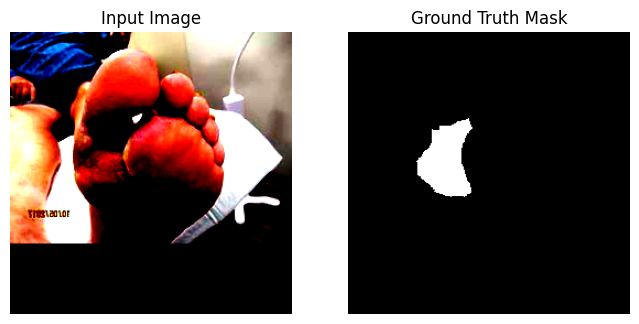

In [ ]:
# ===== Cell 8: Visualize sample =====
image, mask = train_dataset[0]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()


In [ ]:
# ===== Cell 9: Load EfficientNet-B0 backbone =====
from torchvision.models import efficientnet_b0

def get_efficientnet_b0_encoder():
    model = efficientnet_b0(weights="IMAGENET1K_V1")
    return model.features


In [ ]:
# ===== Cell 10: Basic Conv Block =====
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


In [ ]:
# ===== Cell 11: Decoder Block =====
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


In [ ]:
# ===== Cell 12 (FINAL FIX): U-Net + EfficientNet-B0 =====
class UNetEfficientNetB0(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        backbone = efficientnet_b0(weights="IMAGENET1K_V1")
        self.encoder = backbone.features

        # Decoder blocks
        self.dec4 = DecoderBlock(1280, 112, 256)
        self.dec3 = DecoderBlock(256, 40, 128)
        self.dec2 = DecoderBlock(128, 24, 64)
        self.dec1 = DecoderBlock(64, 16, 32)

        # EXTRA upsampling to recover full resolution
        self.dec0 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )

        self.final_conv = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        features = []

        for layer in self.encoder:
            x = layer(x)
            features.append(x)

        e1 = features[1]    # 16 channels (128×128)
        e2 = features[2]    # 24 channels
        e3 = features[3]    # 40 channels
        e4 = features[5]    # 112 channels
        e5 = features[-1]   # 1280 channels (8×8)

        d4 = self.dec4(e5, e4)   # 16×16
        d3 = self.dec3(d4, e3)   # 32×32
        d2 = self.dec2(d3, e2)   # 64×64
        d1 = self.dec1(d2, e1)   # 128×128

        d0 = self.dec0(d1)       # 256×256

        return torch.sigmoid(self.final_conv(d0))


In [ ]:
model = UNetEfficientNetB0().to(device)

x = torch.randn(1, 3, 256, 256).to(device)
y = model(x)

print("Input :", x.shape)
print("Output:", y.shape)


Input : torch.Size([1, 3, 256, 256])
Output: torch.Size([1, 1, 256, 256])


In [ ]:
# ===== Cell 14: Dice Loss =====
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            preds.sum() + targets.sum() + self.smooth
        )
        return 1 - dice


In [ ]:
# ===== Cell 15: Boundary Loss =====
import scipy.ndimage as ndi

class BoundaryLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, preds, targets):
        preds = preds.squeeze(1)
        targets = targets.squeeze(1)

        boundary_targets = []
        for t in targets.cpu().numpy():
            dist_map = ndi.distance_transform_edt(1 - t)
            boundary_targets.append(dist_map)

        boundary_targets = torch.tensor(
            np.stack(boundary_targets),
            dtype=torch.float32,
            device=preds.device
        )

        return torch.mean(preds * boundary_targets)


In [ ]:
# ===== Cell 16: Combined Loss =====
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.7):
        super().__init__()
        self.dice = DiceLoss()
        self.boundary = BoundaryLoss()
        self.alpha = alpha

    def forward(self, preds, targets):
        return self.alpha * self.dice(preds, targets) + \
               (1 - self.alpha) * self.boundary(preds, targets)


In [ ]:
# ===== Cell 16: Combined Loss =====
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.7):
        super().__init__()
        self.dice = DiceLoss()
        self.boundary = BoundaryLoss()
        self.alpha = alpha

    def forward(self, preds, targets):
        return self.alpha * self.dice(preds, targets) + \
               (1 - self.alpha) * self.boundary(preds, targets)


In [ ]:
# ===== Cell 17: Optimizer & Device =====
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNetEfficientNetB0().to(device)

criterion = CombinedLoss(alpha=0.7)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
# ===== Cell 18: Dice Metric =====
def dice_coefficient(preds, targets, smooth=1e-6):
    preds = (preds > 0.5).float()
    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    dice = (2. * intersection + smooth) / (
        preds.sum() + targets.sum() + smooth
    )
    return dice.item()


In [ ]:
# ===== Cell 19: Training Loop =====
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    epoch_dice = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_dice += dice_coefficient(outputs.detach(), masks)

    return epoch_loss / len(loader), epoch_dice / len(loader)


In [ ]:
# ===== Cell 20: Validation Loop =====
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0
    epoch_dice = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            epoch_loss += loss.item()
            epoch_dice += dice_coefficient(outputs, masks)

    return epoch_loss / len(loader), epoch_dice / len(loader)


In [ ]:
# ===== Cell 21 (IMPROVED): Training Controller with Best Epoch Tracking =====
num_epochs = 30
best_val_dice = 0
best_epoch = 0

train_losses, val_losses = [], []
train_dices, val_dices = [], []

for epoch in range(num_epochs):
    train_loss, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_dice = validate_one_epoch(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    # Save best model
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

print(f"\nBest Validation Dice: {best_val_dice:.4f} at Epoch {best_epoch}")


Epoch [1/30] | Train Loss: 11.2916 | Train Dice: 0.0893 | Val Loss: 9.9457 | Val Dice: 0.1214
Epoch [2/30] | Train Loss: 9.4641 | Train Dice: 0.1424 | Val Loss: 8.6649 | Val Dice: 0.1861
Epoch [3/30] | Train Loss: 8.6468 | Train Dice: 0.1701 | Val Loss: 8.1116 | Val Dice: 0.1559
Epoch [4/30] | Train Loss: 8.0415 | Train Dice: 0.1907 | Val Loss: 7.6948 | Val Dice: 0.2390
Epoch [5/30] | Train Loss: 7.5422 | Train Dice: 0.2684 | Val Loss: 7.4056 | Val Dice: 0.2516
Epoch [6/30] | Train Loss: 7.0731 | Train Dice: 0.3573 | Val Loss: 6.5923 | Val Dice: 0.4632
Epoch [7/30] | Train Loss: 6.6783 | Train Dice: 0.4193 | Val Loss: 6.5698 | Val Dice: 0.4370
Epoch [8/30] | Train Loss: 6.2822 | Train Dice: 0.4586 | Val Loss: 6.1582 | Val Dice: 0.4464
Epoch [9/30] | Train Loss: 5.9193 | Train Dice: 0.4910 | Val Loss: 5.7047 | Val Dice: 0.5542
Epoch [10/30] | Train Loss: 5.5480 | Train Dice: 0.5060 | Val Loss: 5.2814 | Val Dice: 0.5449
Epoch [11/30] | Train Loss: 5.2156 | Train Dice: 0.5287 | Val Loss: 

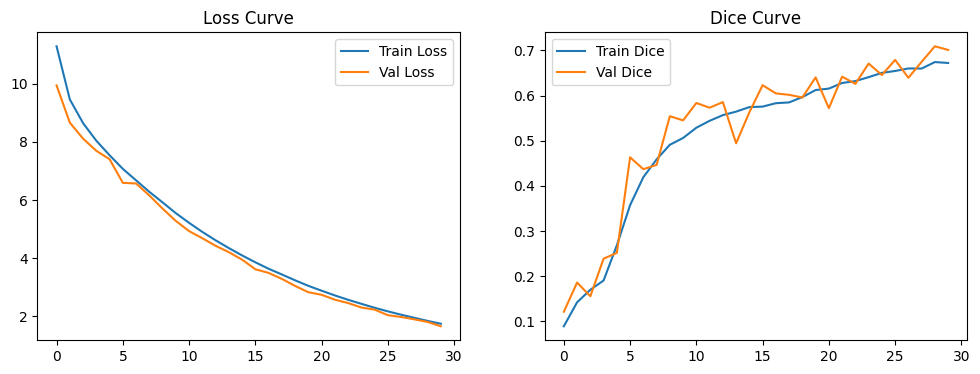

In [ ]:
# ===== Cell 22: Plot Training Curves =====
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_dices, label="Train Dice")
plt.plot(val_dices, label="Val Dice")
plt.title("Dice Curve")
plt.legend()

plt.show()


In [ ]:
# ===== Cell 23: Load Best Model =====
best_model = UNetEfficientNetB0().to(device)
best_model.load_state_dict(torch.load("best_model.pth"))
best_model.eval()


UNetEfficientNetB0(
  (encoder): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormAc

In [ ]:
# ===== Cell 24: Hausdorff Distance =====
from scipy.spatial.distance import directed_hausdorff

def hausdorff_distance(pred, target):
    pred = (pred > 0.5).cpu().numpy()
    target = target.cpu().numpy()

    pred_points = np.argwhere(pred)
    target_points = np.argwhere(target)

    # Skip empty masks
    if len(pred_points) == 0 or len(target_points) == 0:
        return None

    return max(
        directed_hausdorff(pred_points, target_points)[0],
        directed_hausdorff(target_points, pred_points)[0]
    )



In [ ]:
# ===== Cell 25: Final Evaluation =====
def evaluate_model(model, loader, device):
    dices = []
    hausdorffs = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            for i in range(outputs.shape[0]):
                dice = dice_coefficient(outputs[i], masks[i])
                hd = hausdorff_distance(outputs[i][0], masks[i][0])

                dices.append(dice)
                if hd is not None:
                    hausdorffs.append(hd)

    return np.mean(dices), np.mean(hausdorffs)



In [ ]:
# ===== Cell 26: Run Evaluation =====
mean_dice, mean_hd = evaluate_model(best_model, val_loader, device)

print(f"Final Validation Dice       : {mean_dice:.4f}")
print(f"Final Validation Hausdorff  : {mean_hd:.4f}")


Final Validation Dice       : 0.6054
Final Validation Hausdorff  : 15.4398


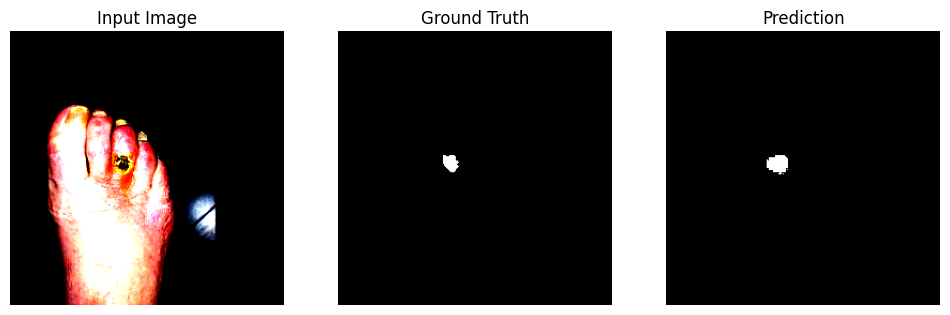

In [ ]:
# ===== Cell 27: Visualization =====
image, mask = val_dataset[0]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    pred = best_model(image)

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().cpu().numpy()
image = image.squeeze().permute(1,2,0).cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.show()


In [ ]:
# =========================================================
# BASELINE U-NET STANDAR (GOOGLE DRIVE - 1 CELL STANDALONE)
# =========================================================

# ---------- Mount Google Drive ----------
from google.colab import drive
drive.mount('/content/drive')

# ---------- Imports ----------
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.spatial.distance import directed_hausdorff
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---------- Device ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- Dataset Path (EDIT IF NEEDED) ----------
BASE_DIR = "/content/drive/MyDrive/Tugas Akhir_Riodino Raihan_Bismillah "

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train/images")
TRAIN_MASK_DIR = os.path.join(BASE_DIR, "train/labels")
VAL_IMG_DIR   = os.path.join(BASE_DIR, "validation/images")
VAL_MASK_DIR  = os.path.join(BASE_DIR, "validation/labels")

print("Train images:", len(os.listdir(TRAIN_IMG_DIR)))
print("Val images  :", len(os.listdir(VAL_IMG_DIR)))

# ---------- Dataset ----------
class FootUlcerDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path  = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"].unsqueeze(0)

        return image, mask

# ---------- Transforms ----------
train_tf = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# ---------- DataLoader ----------
train_loader = DataLoader(
    FootUlcerDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, train_tf),
    batch_size=8, shuffle=True
)

val_loader = DataLoader(
    FootUlcerDataset(VAL_IMG_DIR, VAL_MASK_DIR, val_tf),
    batch_size=8, shuffle=False
)

# ---------- Dice Loss ----------
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = preds.view(-1)
        targets = targets.view(-1)
        inter = (preds * targets).sum()
        dice = (2*inter + self.smooth) / \
               (preds.sum() + targets.sum() + self.smooth)
        return 1 - dice

# ---------- Dice Metric ----------
def dice_score(preds, targets):
    preds = (preds > 0.5).float()
    preds = preds.view(-1)
    targets = targets.view(-1)
    inter = (preds * targets).sum()
    return (2*inter / (preds.sum() + targets.sum() + 1e-6)).item()

# ---------- Hausdorff ----------
def hausdorff(pred, gt):
    pred = (pred > 0.5).cpu().numpy()
    gt   = gt.cpu().numpy()
    p = np.argwhere(pred)
    g = np.argwhere(gt)
    if len(p)==0 or len(g)==0:
        return None
    return max(
        directed_hausdorff(p,g)[0],
        directed_hausdorff(g,p)[0]
    )

# ---------- U-Net Baseline ----------
class UNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()

        def block(i,o):
            return nn.Sequential(
                nn.Conv2d(i,o,3,1,1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.Conv2d(o,o,3,1,1), nn.BatchNorm2d(o), nn.ReLU(inplace=True)
            )

        self.e1 = block(3,64)
        self.e2 = block(64,128)
        self.e3 = block(128,256)
        self.e4 = block(256,512)
        self.pool = nn.MaxPool2d(2)
        self.b  = block(512,1024)

        self.u4 = nn.ConvTranspose2d(1024,512,2,2)
        self.d4 = block(1024,512)
        self.u3 = nn.ConvTranspose2d(512,256,2,2)
        self.d3 = block(512,256)
        self.u2 = nn.ConvTranspose2d(256,128,2,2)
        self.d2 = block(256,128)
        self.u1 = nn.ConvTranspose2d(128,64,2,2)
        self.d1 = block(128,64)

        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b  = self.b(self.pool(e4))

        d4 = self.d4(torch.cat([self.u4(b), e4],1))
        d3 = self.d3(torch.cat([self.u3(d4), e3],1))
        d2 = self.d2(torch.cat([self.u2(d3), e2],1))
        d1 = self.d1(torch.cat([self.u1(d2), e1],1))

        return torch.sigmoid(self.out(d1))

# ---------- Training ----------
model = UNetBaseline().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = DiceLoss()

num_epochs = 30
best_dice = 0

print("\n🚀 Training Baseline U-Net\n")

for epoch in range(num_epochs):
    model.train()
    td = 0
    for img,mask in train_loader:
        img,mask = img.to(device), mask.to(device)
        optimizer.zero_grad()
        out = model(img)
        loss = criterion(out,mask)
        loss.backward()
        optimizer.step()
        td += dice_score(out.detach(),mask)

    model.eval()
    vd = 0
    with torch.no_grad():
        for img,mask in val_loader:
            img,mask = img.to(device), mask.to(device)
            out = model(img)
            vd += dice_score(out,mask)

    td /= len(train_loader)
    vd /= len(val_loader)

    if vd > best_dice:
        best_dice = vd
        torch.save(model.state_dict(),"baseline_unet.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Dice: {td:.4f} | Val Dice: {vd:.4f}")

# ---------- Final Evaluation ----------
model.load_state_dict(torch.load("baseline_unet.pth"))
model.eval()

dices, hds = [], []
with torch.no_grad():
    for img,mask in val_loader:
        img,mask = img.to(device), mask.to(device)
        out = model(img)
        for i in range(out.size(0)):
            dices.append(dice_score(out[i],mask[i]))
            hd = hausdorff(out[i][0], mask[i][0])
            if hd is not None:
                hds.append(hd)

print("\n📊 FINAL BASELINE RESULT (VALIDATION SET)")
print(f"Final Validation Dice      : {np.mean(dices):.4f}")
print(f"Final Validation Hausdorff : {np.mean(hds):.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Train images: 810
Val images  : 200

🚀 Training Baseline U-Net

Epoch [1/30] | Train Dice: 0.2302 | Val Dice: 0.3595
Epoch [2/30] | Train Dice: 0.3468 | Val Dice: 0.2788
Epoch [3/30] | Train Dice: 0.3640 | Val Dice: 0.5035
Epoch [4/30] | Train Dice: 0.4069 | Val Dice: 0.5387
Epoch [5/30] | Train Dice: 0.4724 | Val Dice: 0.6367
Epoch [6/30] | Train Dice: 0.5609 | Val Dice: 0.5532
Epoch [7/30] | Train Dice: 0.5920 | Val Dice: 0.6215
Epoch [8/30] | Train Dice: 0.6483 | Val Dice: 0.7313
Epoch [9/30] | Train Dice: 0.6909 | Val Dice: 0.7488
Epoch [10/30] | Train Dice: 0.7351 | Val Dice: 0.7002
Epoch [11/30] | Train Dice: 0.7708 | Val Dice: 0.7362
Epoch [12/30] | Train Dice: 0.7729 | Val Dice: 0.7885
Epoch [13/30] | Train Dice: 0.8022 | Val Dice: 0.7732
Epoch [14/30] | Train Dice: 0.7981 | Val Dice: 0.7979
Epoch [15/30] | Train Dice: 0.8212 | Val Dice: 